In [5]:
from pathlib import Path
import importlib
import sys

import numpy as np

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "polychrom").is_dir() else cwd.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

TRAJECTORY_DIR = Path("trajectory")
if not TRAJECTORY_DIR.exists():
    TRAJECTORY_DIR = REPO_ROOT / "examples" / "loopExtrusion" / "trajectory"

import polychrom.hdf5_format as hdf5_format
import polychrom.polymerutils as polymerutils
import polychrom.contactmaps as contactmaps

hdf5_format = importlib.reload(hdf5_format)
polymerutils = importlib.reload(polymerutils)
contactmaps = importlib.reload(contactmaps)

list_URIs = hdf5_format.list_URIs
monomerResolutionContactMapSubchains = contactmaps.monomerResolutionContactMapSubchains


In [6]:
URIs = list_URIs(str(TRAJECTORY_DIR))
len(URIs)

10000

In [7]:
starts = list(range(0, 39000, 4000))
starts

[0, 4000, 8000, 12000, 16000, 20000, 24000, 28000, 32000, 36000]

In [8]:
hmap = monomerResolutionContactMapSubchains(
    filenames=URIs,
    mapStarts=starts,
    mapN=4000,
    cutoff=6,
    n=6,
    verbose=True,
)

monomerResolutionContactMapSubchains: starting on 6 processes
monomerResolutionContactMapSubchains: 501/10000 (5.0%), 65.5s
monomerResolutionContactMapSubchains: 1002/10000 (10.0%), 67.2s
monomerResolutionContactMapSubchains: 1503/10000 (15.0%), 84.9s
monomerResolutionContactMapSubchains: 2004/10000 (20.0%), 86.6s
monomerResolutionContactMapSubchains: 2505/10000 (25.1%), 102.6s
monomerResolutionContactMapSubchains: 3006/10000 (30.1%), 105.4s
monomerResolutionContactMapSubchains: 3507/10000 (35.1%), 121.0s
monomerResolutionContactMapSubchains: 4008/10000 (40.1%), 124.7s
monomerResolutionContactMapSubchains: 4509/10000 (45.1%), 139.8s
monomerResolutionContactMapSubchains: 5010/10000 (50.1%), 144.3s
monomerResolutionContactMapSubchains: 5511/10000 (55.1%), 158.4s
monomerResolutionContactMapSubchains: 6012/10000 (60.1%), 162.2s
monomerResolutionContactMapSubchains: 6513/10000 (65.1%), 177.0s
monomerResolutionContactMapSubchains: 7014/10000 (70.1%), 180.3s
monomerResolutionContactMapSubchai

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
def observed_over_expected(contact_map):
    contact_map = np.asarray(contact_map, dtype=float)
    if contact_map.ndim != 2 or contact_map.shape[0] != contact_map.shape[1]:
        raise ValueError("contact_map must be a square matrix")

    n = contact_map.shape[0]
    result = np.full_like(contact_map, np.nan, dtype=float)
    for offset in range(n):
        diag = np.diagonal(contact_map, offset=offset)
        expected = diag.mean()
        if expected <= 0:
            continue
        normalized = diag / expected
        rows = np.arange(n - offset)
        cols = rows + offset
        result[rows, cols] = normalized
        if offset:
            result[cols, rows] = normalized
    return result

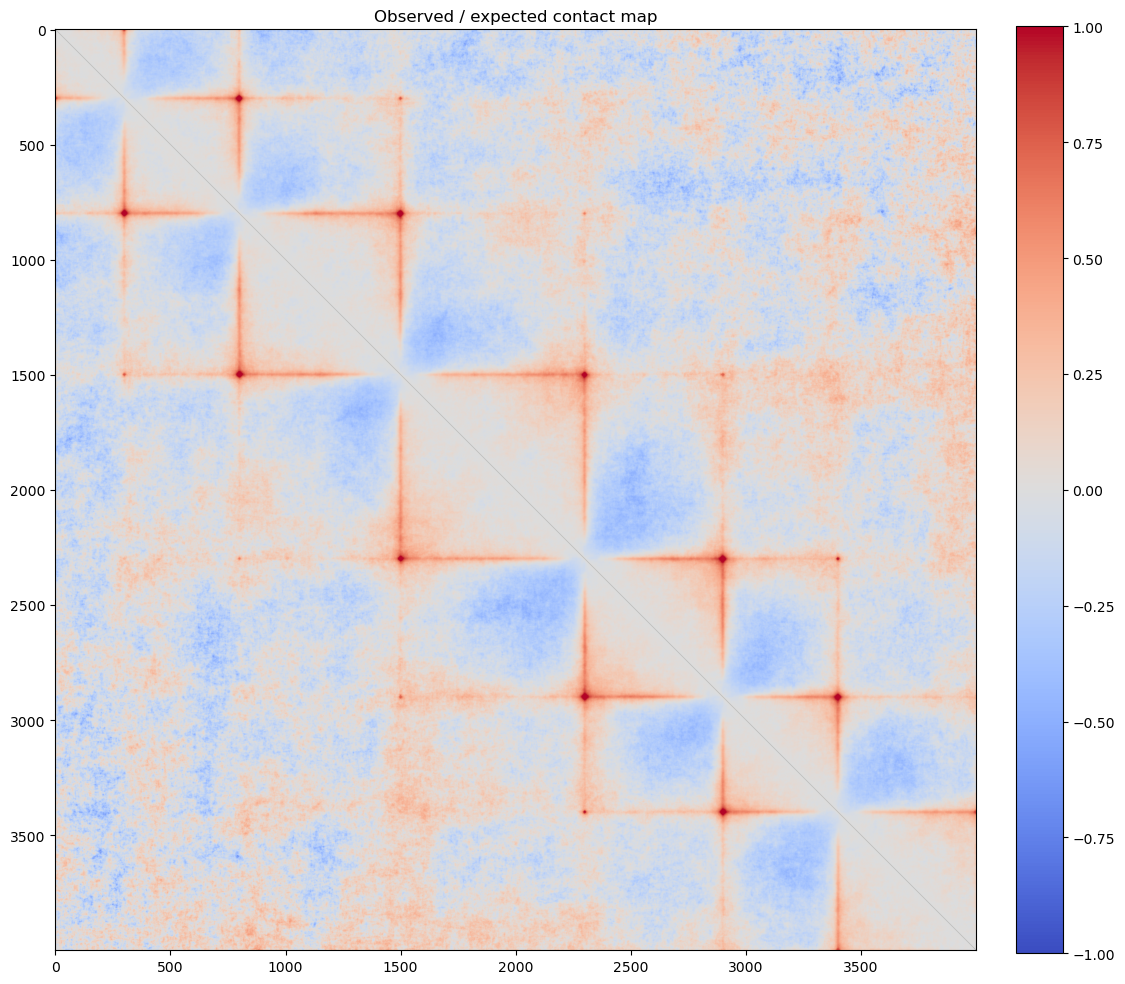

In [11]:
oe = observed_over_expected(hmap)
with np.errstate(divide="ignore", invalid="ignore"):
    log_oe = np.log(oe)

fig, ax = plt.subplots(figsize=(13, 13))
im = ax.imshow(log_oe, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Observed / expected contact map")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()